In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

We deal with LotFrontage and its missing values first

In [121]:
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

Lot Frontage probably depends a lot on the neighbouhood the property is located in. We check this

<Axes: xlabel='Neighborhood'>

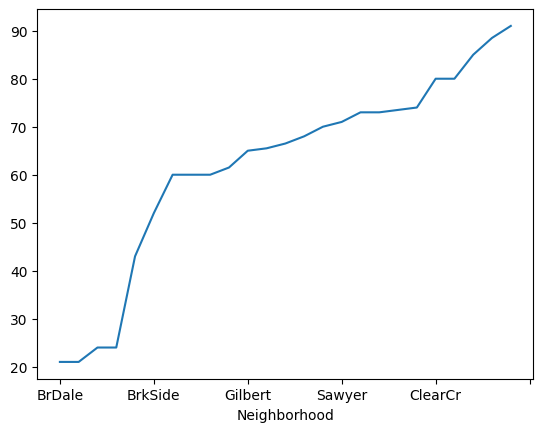

In [122]:
df.groupby("Neighborhood")["LotFrontage"].median().sort_values().plot()

We see clear evidence of it. So we fill the NA values in LotFrontage with the median of each neihghbouhood as its most resistant to outliers and we did see two outliers

In [123]:
df["LotFrontage"] = df["LotFrontage"].fillna(
    df.groupby("Neighborhood")["LotFrontage"].transform("median"))

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

We now deal with Alley

In [125]:
df["Alley"] = df["Alley"].fillna("NA")

In [126]:
res = {}
for k in df.columns:
    s = df[k].isna().sum() 
    if s > 0:
        res[k] = s
res

{'MasVnrType': np.int64(872),
 'MasVnrArea': np.int64(8),
 'BsmtQual': np.int64(37),
 'BsmtCond': np.int64(37),
 'BsmtExposure': np.int64(38),
 'BsmtFinType1': np.int64(37),
 'BsmtFinType2': np.int64(38),
 'Electrical': np.int64(1),
 'FireplaceQu': np.int64(690),
 'GarageType': np.int64(81),
 'GarageYrBlt': np.int64(81),
 'GarageFinish': np.int64(81),
 'GarageQual': np.int64(81),
 'GarageCond': np.int64(81),
 'PoolQC': np.int64(1453),
 'Fence': np.int64(1179),
 'MiscFeature': np.int64(1406)}

In [127]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

We run into a problem because we dont see Cblock anywhere. How many NA values are actually "None" and how many are "Stone", but set to NA ? For now, we set MasVnrType to None wherever MasVnrArea has 0

In [128]:
df.loc[df["MasVnrArea"]==0,"MasVnrType"] = "None"

In [129]:
df["MasVnrType"].describe() #Still 13 missing

count     1447
unique       4
top       None
freq       861
Name: MasVnrType, dtype: object

In [130]:
df[df["MasVnrArea"].isna()]["MasVnrType"] #We opt to set MasVnrType as None and MasVnrArea as 0 in these cases

234     NaN
529     NaN
650     NaN
936     NaN
973     NaN
977     NaN
1243    NaN
1278    NaN
Name: MasVnrType, dtype: object

In [131]:
df.loc[(df["MasVnrArea"].isna() & df["MasVnrType"].isna()),"MasVnrType"] = "None"
df.loc[(df["MasVnrArea"].isna() & df["MasVnrType"].isna()),"MasVnrArea"] = 0

In [132]:
df["MasVnrType"].isna().sum()

np.int64(5)

In [133]:
df.loc[df["MasVnrArea"].isna() | df["MasVnrType"].isna(),
       ["MasVnrArea","MasVnrType"]]

,MasVnrArea,MasVnrType
234,NaN,None
529,NaN,None
624,288.0,NaN
650,NaN,None
773,1.0,NaN
936,NaN,None
973,NaN,None
977,NaN,None
1230,1.0,NaN
1243,NaN,None


In [134]:
df.loc[(df["MasVnrType"] == "None") & (df["MasVnrArea"].isna()), "MasVnrArea"] = 0

In [135]:
df.loc[df["MasVnrArea"].isna() | df["MasVnrType"].isna(),
       ["MasVnrArea","MasVnrType"]]

,MasVnrArea,MasVnrType
624,288.0,NaN
773,1.0,NaN
1230,1.0,NaN
1300,344.0,NaN
1334,312.0,NaN


We now fill the Type, where area > 0, with the mode of the type

In [136]:
df.loc[
    (df["MasVnrArea"] > 0) & (df["MasVnrType"].isna()),
    "MasVnrType"
] = df["MasVnrType"].mode()[0]

In [137]:
df["MasVnrType"].isna().sum()

np.int64(0)

We now deal with Bsmtqual and BsmtCondn. They have the same number of NA values. We just set both column NA values to None

In [138]:
df["BsmtQual"] = df["BsmtQual"].fillna("NA")
df["BsmtCond"] = df["BsmtCond"].fillna("NA") 

In [146]:
df.loc[
    (df["BsmtCond"] == "NA") &
    (df["BsmtQual"] == "NA") &
    (df["BsmtExposure"].isna()),
    "BsmtExposure"
] = "NA"

In [147]:
df.loc[df["BsmtExposure"].isna(),["BsmtCond","BsmtQual"]]

,BsmtCond,BsmtQual
948,TA,Gd


In [154]:
df["BsmtExposure"] = df["BsmtExposure"].fillna("No") 

Now BsmtFinType1

In [156]:
df["BsmtFinType1"] = df["BsmtFinType1"].fillna(0) 

Now BsmtFinType2

In [163]:
df[(df["BsmtQual"] != "NA") & (df["BsmtCond"] != "NA") & (df["BsmtExposure"] != "NA") &
   (df["BsmtFinType2"].isna())][["BsmtQual","BsmtCond","BsmtExposure"]]

,BsmtQual,BsmtCond,BsmtExposure
332,Gd,TA,No


In [ ]:
df[(df["BsmtQual"] == "Gd") & (df["BsmtCond"] == "TA") & (df["BsmtExposure"] == "No")]["BsmtFinType2"].mode()

0    Unf
Name: BsmtFinType2, dtype: object

In [165]:
df.loc[(df["BsmtQual"] != "NA") & (df["BsmtCond"] != "NA") & (df["BsmtExposure"] != "NA") &
   (df["BsmtFinType2"].isna()),"BsmtFinType2"] = "Unf"

In [166]:
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("NA") 

Now Electrical

In [169]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

Now we do FireplaceQu. For all the rows of fireplaces that are 0, we fill the corresponding FireplaceQu as NA

In [171]:
df.loc[(df["Fireplaces"] == 0),"FireplaceQu"] = "NA"

In [ ]:
df["FireplaceQu"].isna().sum() #That worked very well lmao

np.int64(0)

We fill Nan values of GarageType as NA, GarageYrBlt as mode,GarageFinish as NA,GarageQual as NA,GarageCond as NA

In [173]:
df["GarageType"] = df["GarageType"].fillna("NA")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].mode()[0])
df["GarageFinish"] = df["GarageFinish"].fillna("NA")
df["GarageQual"] = df["GarageQual"].fillna("NA")
df["GarageCond"] = df["GarageCond"].fillna("NA")

Now PoolQc. We check which PoolArea are 0. We replace the corresponding PoolQc with NA

In [174]:
df.loc[(df["PoolArea"] == 0),"PoolQC"] = "NA"

In [ ]:
df["PoolQC"].isna().sum() #Worked beautifully

np.int64(0)

`Fence` has structural missingness in Ames—NaN typically means the property has no fence.
Therefore, missing values are filled with `"None"` to explicitly encode absence.


In [176]:
df["Fence"] = df["Fence"].fillna("NA")

In [ ]:
df["Fence"].isna().sum() #Works

np.int64(0)

Same as above for misc feature

In [178]:
df["MiscFeature"] = df["MiscFeature"].fillna("NA")

Thus, we have the final cleaned dataset. We chek if NaN values are left

In [181]:
df.isna().sum().sum()

np.int64(0)

None. We now make a new data file "Train_cleaned.csv"

In [182]:
df.to_csv("data/train_cleaned.csv",index = False)

In [183]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NA,Reg,Lvl,AllPub,...,0,NA,MnPrv,NA,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NA,Reg,Lvl,AllPub,...,0,NA,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,4,2010,WD,Normal,142125
